# `00_bicycle_route_relations`: Bicycle Route Relations and Member Ways

## Introduction

### Purpose

This notebook extracts bicycle route relations from OpenStreetMap and derives the corresponding member ways that constitute the bicycle route network used throughout the analysis.

### Inputs

- OpenStreetMap data (HeiGIT ohsome planet snapshot, 6 October 2025, 13:16:28)
- Dutch administrative area boundary dataset

### Outputs

- `bicycle_route_relations`: relation-level table containing all bicycle route relations extracted from the OSM snapshot.
- `bicycle_route_m_ways_distinct`: distinct member ways of those relations, clipped to the Netherlands administrative boundary.

### Key steps

The notebook proceeds in three steps. First, bicycle route relations are extracted from the HeiGIT ohsome planet snapshot (6 October 2025) by filtering on `type=route`, `route=bicycle`, and `network ∈ {icn, ncn, rcn, lcn}`. While `type=route` and `route=bicycle` identify a relation as a bicycle route, the `network` tag is required here as it encodes the hierarchical classification (international, national, regional, or local) that underpins the analysis. Relations without a valid network value are excluded; of the 17,368 bicycle route relations present in the snapshot for the Netherlands, 7 are removed by this filter. Second, the member ways of the retained relations are unnested, deduplicated, and classified by network level. Ways belonging to more than one network level are assigned a `multiple` classification, reflecting the reality that a single physical way can simultaneously contribute to routes of different hierarchical scope. Third, the resulting ways are clipped to the Netherlands administrative boundary to remove segments extending beyond the extract area, yielding `bicycle_route_m_ways_distinct`. The network is then visualised interactively and statically.

### Dependencies on prior notebooks

- `01_boundaries.ipynb` provides the `nl_admin_area_gdf` GeoDataFrame used to clip ways to the Netherlands administrative boundary.

### Table of contents

1. [Environment setup](#1-environment-setup)
2. [Core functions](#2-core-functions)
3. [Bicycle route relations](#3-bicycle-route-relations)
   - 3.1 [Extract relations](#31-extract-relations)
   - 3.2 [Excluded relations](#32-excluded-relations)
   - 3.3 [Result: `bicycle_route_relations`](#33-result-bicycle_route_relations)
4. [Bicycle route relation member ways](#4-bicycle-route-relation-member-ways)
   - 4.1 [Extract and unnest member ways](#41-extract-and-unnest-member-ways)
   - 4.2 [Deduplicate and classify by network type](#42-deduplicate-and-classify-by-network-type)
5. [Clip to Netherlands administrative boundary](#5-clip-to-netherlands-administrative-boundary)
   - 5.1 [Result: `bicycle_route_m_ways_distinct`](#51-result-bicycle_route_m_ways_distinct)
6. [Visualisation](#6-visualisation)
   - 6.1 [Interactive map](#61-interactive-map)
   - 6.2 [Static map](#62-static-map)

---

## 1. Environment setup


### Libraries and extensions

Import the required Python libraries and load the DuckDB Spatial extension.

In [2]:
import contextily as cx
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.utils import io
from lonboard import Map, PathLayer, viz
from lonboard.basemap import CartoStyle, MaplibreBasemap
from lonboard.colormap import apply_categorical_cmap
from shapely import wkt

In [3]:
duckdb.sql("INSTALL spatial; LOAD spatial")

### Loading shared variables

Load the Dutch administrative boundary layer (`nl_admin_area_gdf`) produced in `01_boundaries.ipynb`.

In [17]:
with io.capture_output() as captured:
    %run /home/vbo226/01_boundaries.ipynb # nl_admin_area_gdf

### OpenStreetMap dataset

Define the path to the OSM parquet files used throughout the analysis.

In [5]:
# HeiGIT ohsome planet latest snapshot (6 October 2025, 13:16:28)
osm_data_path = '/local/data/vbo226/my_dataset/*.parquet'

---

## 2. Core functions

The function below clips ways from any source table to the Netherlands administrative boundary, computing the intersection length in EPSG:28992. The ways table name and geometry column are passed as parameters, making the function reusable across notebooks.

In [19]:
def clip_osm_to_nl_admin_area(ways_table, geom_col):
    nl_admin_area_arrow = nl_admin_area_gdf.to_arrow()
    return duckdb.sql(f"""
    SELECT 
        w.* RENAME(w.length AS length_osm_meters), 
        ROUND(
            ST_Length(ST_Transform(ST_Intersection(nl.geometry, w.{geom_col}),'EPSG:4326', 'EPSG:28992', always_xy := true)), 2) AS length_nl_meters
    FROM {ways_table} w
    JOIN nl_admin_area_arrow nl
      ON ST_Intersects(nl.geometry, w.{geom_col})
    """)

---

## 3. Bicycle route relations

### Conceptual background

In OpenStreetMap, bicycle routes are commonly represented as **route relations** that group multiple road segments into a logical route. Bicycle route relations are identified by the following tagging structure:

- `type=route`
- `route=bicycle`
- `network ∈ {icn, ncn, rcn, lcn}`

While `type` and `route` serve as the core identifiers, the `network` tag is required here as it encodes the hierarchical level of the cycling route, a prerequisite for the classification used throughout the analysis:

| Value | Meaning |
|---|---|
| `icn` | International cycling network |
| `ncn` | National cycling network |
| `rcn` | Regional cycling network |
| `lcn` | Local cycling network |

**Named bicycle routes vs node-network bicycle route relations.** In the Netherlands, both main OSM route structures exist. International, national, and local routes are represented as named bicycle route relations. The regional cycling network is primarily implemented as a node-network (*knooppuntennetwerk*), where numbered junctions are connected by signed cycling segments. Node-network route relations are tagged with both `network=rcn` and `network:type=node_network`, as defined by the Dutch OSM tagging conventions for cycle routes. Named regional route relations carry `network=rcn` without `network:type`. The filter applied here (`type=route`, `route=bicycle`, `network ∈ {icn, ncn, rcn, lcn}`) captures both structures, since node-network relations satisfy the filter through `network=rcn` just as named relations do. No additional condition on `network:type=node_network` is applied; both route structures are retained.

### 3.1 Extract relations

The query below selects all OSM relations matching the bicycle-route tagging structure described above and derives the per-relation identifiers, tags, and member-way lists used in subsequent steps.

In [6]:
bicycle_route_relations_base = duckdb.sql(f"""
SELECT *,
    format('{{}}/{{}}', osm_id, osm_type) as bicycle_relation_id,
    tags['network'] as network_type,
    tags as bicycle_relation_tags,
    members as bicycle_relation_members,
    list_apply(list_filter(members, x -> x.type = 'way' AND x.geometry IS NOT NULL), x -> format('{{}}/{{}}', x.id, x.type)) as way_m_ids,
    list_apply(list_filter(members, x -> x.type = 'way' AND x.geometry IS NOT NULL), x -> st_geomfromwkb(x.geometry)) as way_m_geoms,
FROM read_parquet('{osm_data_path}')
WHERE 1=1
AND osm_type = 'relation'
AND map_contains_entry(tags, 'type', 'route')
AND map_contains_entry(tags, 'route', 'bicycle')
AND (map_contains_entry(tags, 'network', 'icn')
    OR map_contains_entry(tags, 'network', 'ncn')
    OR map_contains_entry(tags, 'network', 'rcn')
    OR map_contains_entry(tags, 'network', 'lcn')
    )
""")

#### Route classification

Each relation is assigned an `inferred_route_type` capturing the role it plays in the Dutch cycling network. The classification is evaluated in priority order; the first matching branch wins. The categories produced are:

| Category | Description |
|---|---|
| `node_network` | Dutch knooppuntennetwerk relations (`network:type=node_network`); the regional point-to-point junction system. |
| `foreign` | Cross-border relations operated by non-Dutch authorities or identified by foreign cycle-network refs, websites, or Wikipedia entries. |
| `fietssnelweg` | High-quality intercity cycling highways (`cycle_highway=yes`); classified by Dutch OSM convention as regional (`network=rcn`). |
| `EuroVelo` | Pan-European routes (`network=icn`) carrying EuroVelo identifiers via `cycle_network`, `name`, or `ref`. |
| `international_non_eurovelo` | Remaining `network=icn` routes without EuroVelo identification (e.g. Euroroute R1). |
| `LF_route` | Dutch national long-distance recreational routes (`LF*`, Elfstedenroute, Fietsallee). |
| `other_dutch_national` | `network=ncn` routes not classified as LF or fietssnelweg. |
| `standard_regional` | Named `network=rcn` routes outside the node network. |
| `fietsnet` | Municipal cycling networks (Fietsnet/Routenet). |
| `utility_route` | Functional commuter routes identified by `bicycle:type=utility`. |
| `questionable` | Routes flagged via `fixme` notes regarding signage. |
| `lcn_recreational` | Remaining `network=lcn` routes (provincial recreation, tourism loops, basic networks). |
| `unclassified` | Anything not matching the rules above. |

The summary table below confirms the assigned category for each `network` value.

In [7]:
bicycle_route_relations = duckdb.sql("""
WITH classified AS (
    SELECT *,
    CASE 
        WHEN map_contains_entry(tags, 'network:type', 'node_network')
        THEN 'node_network'

        WHEN tags['operator'] IN (
                'Sustrans',
                'Service public de Wallonie',
                'Service Public de Wallonie',
                'Stad Antwerpen',
                'Toerisme Provincie Antwerpen',
                'Maison du Tourisme du Pays de Herve',
                'Hasetal Touristik GmbH',
                'Stichting Europafietsers',
                'gemeente Bocholt',
                'VVV Nordhorn'
            )
            OR tags['cycle_network'] LIKE 'UK:%'
            OR tags['cycle_network'] LIKE 'BE-%'
            OR tags['cycle_network'] LIKE 'BE:%'
            OR tags['cycle_network'] = 'BE:RAVeL'
            OR (tags['ref'] LIKE 'D%' AND tags['name'] LIKE '%D-Netz%')
            OR (tags['ref'] LIKE 'D%' AND tags['name'] LIKE '%D8%')
            OR tags['website'] LIKE '%wayoftheroses%'
            OR tags['website'] LIKE '%grafschaft-bentheim%'
            OR tags['website'] LIKE '%heinsberger-land%'
            OR tags['website'] LIKE '%fietssnelwegen.be%'
            OR tags['website'] LIKE '%paysdeherve.be%'
            OR tags['website'] LIKE '%kempen.be%'
            OR tags['website'] LIKE '%suedliches-ostfriesland%'
            OR tags['url'] LIKE '%grafschaft-bentheim%'
            OR tags['operator'] LIKE '%Stadt %'
            OR tags['operator'] LIKE '%Kreis %'
            OR tags['operator'] LIKE '%Ministerium%'
            OR tags['operator'] LIKE '%Samtgemeinde%'
            OR tags['operator'] LIKE '%Gemeente Stekene%'
            OR tags['operator'] LIKE '%Gemeente Bocholt%'
            OR tags['operator'] LIKE '%Sint-Gillis%'
            OR tags['operator'] LIKE '%Cultuur & Toerisme%'
            OR tags['operator'] LIKE '%Nordhorn%'
            OR tags['name'] LIKE '%Radrundwanderweg%'
            OR tags['name'] LIKE '%NiederRhein%'
            OR tags['name'] LIKE '%D-Netz%'
            OR tags['name'] LIKE '%Grafschafter%'
            OR tags['ref'] LIKE 'NRR-%'
            OR (tags['wikipedia'] LIKE 'de:%' AND tags['name:nl'] IS NULL)
        THEN 'foreign'

        WHEN map_contains_entry(tags, 'cycle_highway', 'yes')
        THEN 'fietssnelweg'

        WHEN map_contains_entry(tags, 'network', 'icn')
            AND (
                map_contains_entry(tags, 'cycle_network', 'EuroVelo')
                OR tags['name'] LIKE '%EuroVelo%'
                OR tags['ref'] LIKE '%EV%'
            )
        THEN 'EuroVelo'

        WHEN map_contains_entry(tags, 'network', 'icn')
        THEN 'international_non_eurovelo'

        WHEN tags['operator'] IN ('Nederland Fietsland', 'Fietsplatform')
            OR tags['ref'] LIKE 'LF%'
            OR tags['ref'] = 'Elf'
            OR tags['wikipedia'] LIKE '%LF%'
            OR tags['wikipedia'] LIKE '%Landelijke fietsroute%'
            OR tags['name:nl'] = 'Fietsallee langs de Noordervaart'
        THEN 'LF_route'

        WHEN map_contains_entry(tags, 'network', 'ncn')
        THEN 'other_dutch_national'

        WHEN map_contains_entry(tags, 'network', 'rcn')
        THEN 'standard_regional'

        WHEN tags['cycle_network'] LIKE 'Fietsnet%'
            OR tags['cycle_network'] LIKE 'Routenet%'
        THEN 'fietsnet'

        WHEN map_contains_entry(tags, 'bicycle:type', 'utility')
        THEN 'utility_route'

        WHEN tags['fixme'] LIKE '%bewegwijzerd%'
            OR tags['fixme'] LIKE '%uitgeschildert%'
        THEN 'questionable'

        WHEN map_contains_entry(tags, 'network', 'lcn')
            OR map_contains_entry(tags, 'network:type', 'basic_network')
        THEN 'lcn_recreational'

        ELSE 'unclassified'

    END AS inferred_route_type
    FROM bicycle_route_relations_base
)
SELECT *
FROM classified
""")

duckdb.sql("""
SELECT tags['network'], inferred_route_type, COUNT(*) as relations, ROUND(100.0 * COUNT(*) / SUM(relations) OVER (), 3) AS share
FROM bicycle_route_relations
GROUP BY tags['network'], inferred_route_type
ORDER BY share DESC;
""").show(max_width=150, max_rows=70)

┌─────────────────┬────────────────────────────┬───────────┬────────┐
│ tags['network'] │    inferred_route_type     │ relations │ share  │
│     varchar     │          varchar           │   int64   │ double │
├─────────────────┼────────────────────────────┼───────────┼────────┤
│ rcn             │ node_network               │     16858 │ 97.064 │
│ lcn             │ lcn_recreational           │       165 │   0.95 │
│ ncn             │ LF_route                   │        81 │  0.466 │
│ rcn             │ fietssnelweg               │        61 │  0.351 │
│ lcn             │ utility_route              │        40 │   0.23 │
│ lcn             │ foreign                    │        37 │  0.213 │
│ ncn             │ foreign                    │        25 │  0.144 │
│ rcn             │ standard_regional          │        21 │  0.121 │
│ lcn             │ fietsnet                   │        20 │  0.115 │
│ icn             │ EuroVelo                   │        16 │  0.092 │
│ rcn             │ 

> **Note on missing geometries.** The `members` field of each relation can contain both junction nodes (`type='node'`) and route segment ways (`type='way'`). Only way geometries are relevant here. Ways where `geometry IS NOT NULL` are retained; missing geometries are not data errors — they occur when route segments extend beyond the Netherlands boundary in the ohsome planet extract.

### 3.2 Excluded relations

### 3.2 Excluded relations

By restricting to relations with valid `network` values, **7 relations** are excluded:

- **6 relations** where the `network` tag is `NULL` (key not present).
- **1 legacy ANWB route system entry** (deprecated; see [community discussion](https://community.openstreetmap.org/t/verwijderen-verouderde-anwb-fietsroutes-noord-holland/84443)).

The two queries below confirm the count of excluded relations and the total length of their member ways (recomputed from geometry, since the `length` column is unreliable for these relations).

In [8]:
duckdb.sql(f"""
SELECT
    COUNT(*) AS relation_count,
    SUM(length) / 1000.0 AS length
FROM read_parquet('{osm_data_path}')
WHERE osm_type = 'relation'
  AND map_contains_entry(tags, 'type', 'route')
  AND map_contains_entry(tags, 'route', 'bicycle')
  AND NOT (
      map_contains_entry(tags, 'network', 'icn')
      OR map_contains_entry(tags, 'network', 'ncn')
      OR map_contains_entry(tags, 'network', 'rcn')
      OR map_contains_entry(tags, 'network', 'lcn')
  )
""").show(max_width=150)

┌────────────────┬────────┐
│ relation_count │ length │
│     int64      │ double │
├────────────────┼────────┤
│              7 │    0.0 │
└────────────────┴────────┘



In [9]:
duckdb.sql(f"""
WITH get_length AS (
SELECT 
    osm_id as relation_id,
    list_apply(list_filter(members, x -> x.type = 'way' AND x.geometry IS NOT NULL), x -> st_geomfromwkb(x.geometry)) as way_m_geoms,
FROM read_parquet('{osm_data_path}')
WHERE osm_type = 'relation'
  AND map_contains_entry(tags, 'type', 'route')
  AND map_contains_entry(tags, 'route', 'bicycle')
  AND NOT (
      map_contains_entry(tags, 'network', 'icn')
      OR map_contains_entry(tags, 'network', 'ncn')
      OR map_contains_entry(tags, 'network', 'rcn')
      OR map_contains_entry(tags, 'network', 'lcn')
  )
)
SELECT 
    COUNT(*), 
    SUM(list_sum(list_apply(way_m_geoms, g -> ST_Length(ST_Transform(g, 'EPSG:4326', 'EPSG:28992'))/ 1000.0))) AS length_km
FROM get_length
""").show(max_width=150)

┌──────────────┬───────────────────┐
│ count_star() │     length_km     │
│    int64     │      double       │
├──────────────┼───────────────────┤
│            7 │ 4.537101606997836 │
└──────────────┴───────────────────┘



### 3.3 Result: `bicycle_route_relations`

`bicycle_route_relations` is the relation-level table, with one row per bicycle route relation. The cells below summarise the total relation count and the distribution across network types.

In [10]:
total_relations = duckdb.sql("""
    SELECT COUNT(*) FROM bicycle_route_relations
""").fetchone()[0]
 
print(f"Total bicycle route relations: {total_relations:,}")

Total bicycle route relations: 17,368


In [11]:
# Group bicycle route relations by network type (icn, ncn, rcn, lcn)
# Count relations per network type and compute each type's share of total
duckdb.sql("""
    SELECT
        network_type                                AS network,
        COUNT(*)                                                AS relations_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2)     AS pct_of_total
    FROM bicycle_route_relations
    GROUP BY network_type
    ORDER BY relations_count DESC
""").show(max_width=150)

┌─────────┬─────────────────┬──────────────┐
│ network │ relations_count │ pct_of_total │
│ varchar │      int64      │    double    │
├─────────┼─────────────────┼──────────────┤
│ rcn     │           16964 │        97.67 │
│ lcn     │             264 │         1.52 │
│ ncn     │             118 │         0.68 │
│ icn     │              22 │         0.13 │
└─────────┴─────────────────┴──────────────┘



## 4. Bicycle route relation member ways

Ways in OpenStreetMap can belong to multiple bicycle route relations simultaneously. Individual route segments may therefore be shared across different hierarchical network levels. This section unnests, deduplicates, and classifies all member ways from the retained relations.

### 4.1 Extract and unnest member ways

Member way IDs and geometries are stored as lists in `bicycle_route_relations`. This step unnests them into one row per way–relation pair, forming the many-to-many intermediate table.

In [14]:
bicycle_route_m_ways = duckdb.sql(f"""
WITH way_m_ids AS (
SELECT * EXCLUDE(way_m_ids, way_m_geoms), 
        unnest(way_m_ids) as way_m_id,
        unnest(way_m_geoms) as way_m_geom,
        generate_subscripts(way_m_ids, 1) as unnest_index
FROM bicycle_route_relations
)
SELECT w.*, o.tags as way_m_tags, o.length as way_m_length_meters,
FROM way_m_ids w
INNER JOIN read_parquet('{osm_data_path}') o
ON split_part(w.way_m_id, '/', 1) = o.osm_id
AND o.osm_type = 'way'
""")

### 4.2 Deduplicate and classify by network type

### 4.2 Deduplicate and classify by network type

Each distinct way is assigned a network classification based on the set of relations it participates in:

| Value | Meaning |
|---|---|
| `icn` | Way belongs exclusively to the international network |
| `ncn` | Way belongs exclusively to the national network |
| `rcn` | Way belongs exclusively to the regional network |
| `lcn` | Way belongs exclusively to the local network |
| `multiple` | Way belongs to more than one network category |

In [15]:
bicycle_route_m_ways_distinct_osm = duckdb.sql("""
WITH base AS (
SELECT  
    list(bicycle_relation_id) as bicycle_relation_ids, 
    list(network_type) as network_types,
    list_histogram(list(network_type)) as network_type_counts, 
    list(inferred_route_type) as inferred_route_types,
    list_histogram(list(inferred_route_type)) as inferred_route_type_counts, 
  
    
    way_m_id, 
    way_m_geom, 
    way_m_tags,
    way_m_length_meters, 
    
FROM bicycle_route_m_ways
GROUP BY way_m_id, way_m_geom, way_m_tags, way_m_length_meters
)
SELECT *, 
    CASE
        WHEN len(network_types) == 1 AND network_types[1] == 'icn' 
        THEN 'icn'
        
        WHEN len(network_types) == 1 AND network_types[1] == 'ncn' 
        THEN 'ncn'
        
        WHEN len(network_types) == 1 AND network_types[1] == 'rcn' 
        THEN 'rcn'
        
        WHEN len(network_types) == 1 AND network_types[1] == 'lcn' 
        THEN 'lcn'
        
        WHEN len(network_types) > 1 THEN 'multiple'
        
    END AS way_m_bicycle_network_type_class,
FROM base
""")

## 5. Clip to Netherlands administrative boundary

Ways in `bicycle_route_m_ways_distinct_osm` may extend beyond the Netherlands boundary, for instance, segments of cross-border international routes. This step applies the `clip_osm_to_nl_admin_area` function defined in Section 2 to clip all ways to the Netherlands administrative area, drop segments falling entirely outside, and recompute length using the clipped geometry.

In [20]:
bicycle_route_m_ways_distinct = clip_osm_to_nl_admin_area(
    ways_table='bicycle_route_m_ways_distinct_osm',
    geom_col='way_m_geom'
)

bicycle_route_m_ways_distinct = duckdb.sql("""
SELECT * EXCLUDE(way_m_length_meters),
    length_nl_meters AS way_m_length_nl_meters
FROM bicycle_route_m_ways_distinct
""")

### 5.1 Result: `bicycle_route_m_ways_distinct`

`bicycle_route_m_ways_distinct` is the primary output of this notebook. It contains one row per unique OSM way, clipped to the Netherlands administrative boundary, with lengths computed in EPSG:28992. It feeds directly into `05_bicycle_route_m_ways_distinct_per_spatial_unit`.

In [21]:
total_ways_osm = duckdb.sql("""
    SELECT COUNT(*) FROM bicycle_route_m_ways_distinct_osm
""").fetchone()[0]

total_ways_nl = duckdb.sql("""
    SELECT COUNT(*) FROM bicycle_route_m_ways_distinct
""").fetchone()[0]

total_length_km = duckdb.sql("""
    SELECT ROUND(SUM(length_nl_meters) / 1000, 3)
    FROM bicycle_route_m_ways_distinct
""").fetchone()[0]

print(f"Distinct ways (OSM, unclipped): {total_ways_osm:>10,}")
print(f"Distinct ways (clipped to NL):  {total_ways_nl:>10,}")
print(f"Ways dropped by clipping:       {total_ways_osm - total_ways_nl:>10,}")
print(f"Total length (clipped to NL):   {total_length_km:>10,.3f} km")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Distinct ways (OSM, unclipped):    183,135
Distinct ways (clipped to NL):     181,318
Ways dropped by clipping:            1,817
Total length (clipped to NL):   38,570.854 km


In [22]:
print("Distribution of ways in bicycle route relations by network membership (icn, ncn, rcn, lcn, multiple)")

duckdb.sql("""
    SELECT
        way_m_bicycle_network_type_class,
        COUNT(*)                                                AS ways_count,
        ROUND(SUM(length_nl_meters) / 1000, 3)                 AS length_km,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2)     AS pct_of_ways,
        ROUND(SUM(length_nl_meters) * 100.0
              / SUM(SUM(length_nl_meters)) OVER (), 2)          AS pct_of_length
    FROM bicycle_route_m_ways_distinct
    GROUP BY way_m_bicycle_network_type_class
    ORDER BY ways_count DESC
""").show(max_width=150)

Distribution of ways in bicycle route relations by network membership (icn, ncn, rcn, lcn, multiple)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────────────────┬────────────┬───────────┬─────────────┬───────────────┐
│ way_m_bicycle_network_type_class │ ways_count │ length_km │ pct_of_ways │ pct_of_length │
│             varchar              │   int64    │  double   │   double    │    double     │
├──────────────────────────────────┼────────────┼───────────┼─────────────┼───────────────┤
│ rcn                              │     131449 │ 29744.535 │        72.5 │         77.12 │
│ multiple                         │      42815 │  7721.134 │       23.61 │         20.02 │
│ lcn                              │       6601 │  1035.258 │        3.64 │          2.68 │
│ ncn                              │        287 │    38.307 │        0.16 │           0.1 │
│ icn                              │        166 │     31.62 │        0.09 │          0.08 │
└──────────────────────────────────┴────────────┴───────────┴─────────────┴───────────────┘



## 6. Visualisation

In [24]:
# # Convert into GeoDataFrame for visualization 
bicycle_route_m_ways_distinct_gdf = gpd.GeoDataFrame.from_arrow(bicycle_route_m_ways_distinct.arrow())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### 6.1 Interactive map

In [ ]:
# Large output (may crash computer) that's why uncommented 

# # Define a Discrete colormap by network membership
# cmap = {
#     'icn': [0, 68, 136],
#     'ncn': [220, 50, 32],
#     'rcn': [120, 120, 120],
#     'lcn': [200, 200, 200],
#     'multiple': [0, 0, 0]
# }
 
# # Basemap styling parameters
# basemap = MaplibreBasemap(mode='interleaved', style=CartoStyle.Positron)

# # Define line widths by network importance
# width_map = {
#     'icn': 3.8,        # strong backbone
#     'ncn': 3.0,        # main structure
#     'rcn': 1.8,        # slightly emphasized (dense network)
#     'lcn': 0.8,        # VERY thin (important!)
#     'multiple': 5.0    # strongest highlight
# }

# # # Map network membership to line widths
# # bicycle_route_m_ways_distinct_gdf['line_width'] = bicycle_route_m_ways_distinct_gdf['way_m_bicycle_network'].map(width_map)

# # Create layer 
# bicycle_route_network_layer = PathLayer.from_geopandas(bicycle_route_m_ways_distinct_gdf, get_color='blue', width_min_pixels=1)

# # Render mapbicycle_route_m_ways_distinct_gdf
# #Map(bicycle_route_network_layer, basemap=basemap, view_state = {'longitude': 5.2913, 'latitude': 52.1326, 'zoom': 6})                                                       

### 6.2 Static map

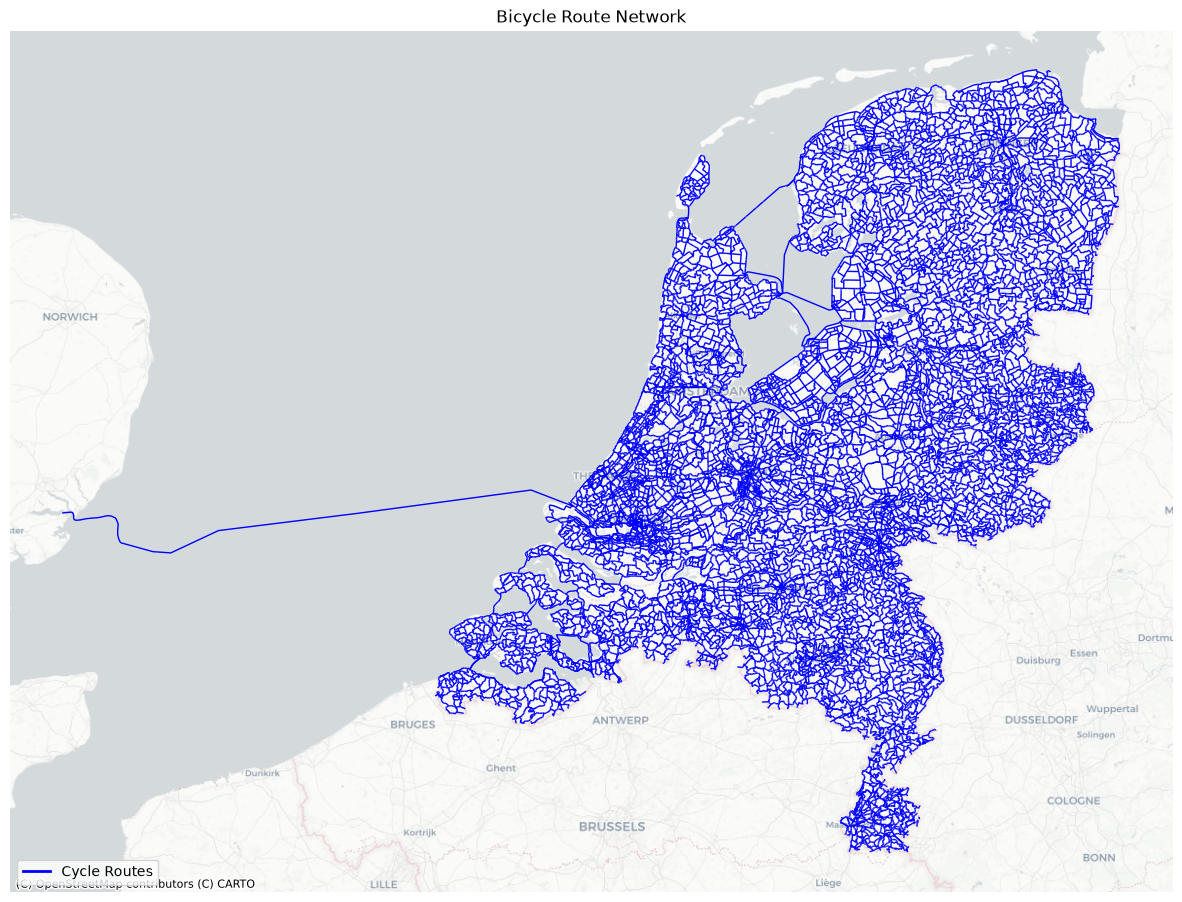

In [25]:
# Create plot
fig, ax = plt.subplots(figsize=(15, 15), dpi=300)

# Set CRS
bicycle_route_m_ways_distinct_gdf = bicycle_route_m_ways_distinct_gdf.set_crs('EPSG:4326')

# Ensure same CRS for basemap (Web Mercator)
bicycle_route_m_ways_distinct_gdf = bicycle_route_m_ways_distinct_gdf.to_crs(epsg=3857)

# Render map
bicycle_route_m_ways_distinct_gdf.plot(ax=ax, color='blue', linewidth=1)

# Add Carto Positron basemap (with labels)
cx.add_basemap(ax,source=cx.providers.CartoDB.Positron,zoom=8)

# Map view styling
ax.set_title("Bicycle Route Network")
ax.set_axis_off()

# Add legend 
import matplotlib.lines as mlines
legend_line = mlines.Line2D([], [], color='blue', linewidth=2, label='Cycle Routes')

ax.legend(handles=[legend_line], loc='lower left')

plt.show()